In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import cv2
import os
from tqdm import tqdm

from torchvision.transforms import v2

from utils import preprocessing_remove_lines, is_char_correct_with_allowance, split_into_char_images

In [2]:
source_folder = "test/"
captcha_files = [f for f in os.listdir(source_folder) if f.lower().endswith(".png")]
if not captcha_files:
    raise FileNotFoundError(f"No Captcha files found in {source_folder}")

# Setup GPU

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


# Setup CNN-Attention Transformer Model

In [4]:
char_classes = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "a": 10,
    "b": 11,
    "c": 12,
    "d": 13,
    "e": 14,
    "f": 15,
    "g": 16,
    "h": 17,
    "i": 18,
    "j": 19,
    "k": 20,
    "l": 21,
    "m": 22,
    "n": 23,
    "o": 24,
    "p": 25,
    "q": 26,
    "r": 27,
    "s": 28,
    "t": 29,
    "u": 30,
    "v": 31,
    "w": 32,
    "x": 33,
    "y": 34,
    "z": 35,
}
num_classes = len(char_classes)
print(num_classes)

36


In [5]:
from model import ImageSequenceClassifier

net = torch.load("char_classification_transformer_model.pth", map_location=device, weights_only=False)
net.to(device)
net.eval()

def count_params(net, trainable=False):
    if trainable:
        count = sum(p.numel() for p in net.parameters() if p.requires_grad)
    else:
        count = sum(p.numel() for p in net.parameters())
    return count

print(F'Network has {count_params(net, trainable=False)} parameters in total')
print(F'Network has {count_params(net, trainable=True)} trainable parameters in total')

Network has 636420 parameters in total
Network has 636420 trainable parameters in total


# Eval Single Image

In [6]:
import torch
import cv2
from torchvision import transforms

def predict_captcha(model, img, char_classes, device='cuda'):
    """
    Predict the captcha string for a single captcha image.
    
    Args:
        model: trained ImageSequenceClassifier model
        image_path: path to captcha image
        char_classes: dict mapping char -> index
        device: 'cuda' or 'cpu'
    
    Returns:
        predicted string
    """
    model.eval()
    
    # Read image
    if img is None:
        raise FileNotFoundError(f"Cannot read image")
    
    # Split into character images
    char_imgs = split_into_char_images(img)  # your existing function
    
    # Transform character images
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor()  # output shape: [1, H, W]
    ])
    char_tensors = [transform(cv2.resize(ch, (42, 42))) for ch in char_imgs]
    
    # Stack into [N, C, H, W]
    x = torch.stack(char_tensors).unsqueeze(0).to(device)  # [1, N, C, H, W]
    
    # Create mask
    mask = torch.ones(1, x.size(1), dtype=torch.bool).to(device)
    
    # Forward pass
    with torch.no_grad():
        logits = model(x, mask)       # [1, N, num_classes]
        preds = logits.argmax(dim=-1) # [1, N]
    
    # Map back to characters
    idx_to_char = {v: k for k, v in char_classes.items()}
    pred_chars = [idx_to_char[i.item()] for i in preds[0, :mask.sum()]]
    
    return pred_chars

Predicted captcha: ['o', 'o', '7', 's', 'h', '2', 'w', 'p']


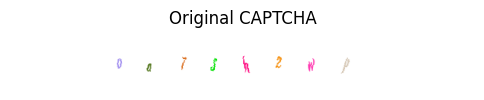

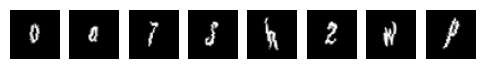

In [7]:
test_captcha_path = "test/0a7sh2wp-0.png"
test_captcha_img = cv2.imread(test_captcha_path)
predicted = predict_captcha(net, test_captcha_img, char_classes, device=device)
print("Predicted captcha:", predicted)

# Show the captcha
plt.figure(figsize=(6, 3))
plt.imshow(cv2.cvtColor(test_captcha_img, cv2.COLOR_BGR2RGB))  # Convert BGR → RGB
plt.title("Original CAPTCHA")
plt.axis('off')
plt.show()

test_char_images = split_into_char_images(test_captcha_img)
plt.figure(figsize=(6, 3))
for i, char_img in enumerate(test_char_images):
    plt.subplot(1, len(test_char_images), i + 1)
    plt.imshow(char_img, cmap='gray')
    plt.axis('off')
plt.show()

# Eval on whole test set

In [8]:
test_folder = "test/" # "clean_test/"
captcha_files = [f for f in os.listdir(test_folder) if f.lower().endswith(".png")]
if not captcha_files:
    raise FileNotFoundError(f"No Captcha files found in {test_folder}")

images_count = 0
wrong_char_num_count = 0
correct = 0
correct_with_allowance = 0

character_count = 0
correct_char_count = 0
correct_char_count_with_allowance = 0

for (root,dirs,files) in os.walk(test_folder,topdown=True):
    for file in tqdm(files, desc="Loading images"):
        if file.endswith('.png'):
            if file[1] == "_":
                os.remove(os.path.join(root, file))
                continue
            if len(file.split("-")[1].split(".png")[0]) != 1: # remove any images marked wrong (train data)
                #print(file)
                continue

            images_count += 1

            correct_char_array = list(file.split("-")[0])
            character_count += len(correct_char_array)
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            predicted_char_array = predict_captcha(net, img, char_classes, device=device)

            correct_char_count += sum(c1 == c2 for c1, c2 in zip(correct_char_array, predicted_char_array))
            correct_char_count_with_allowance += sum(is_char_correct_with_allowance(c1, c2) for c1, c2 in zip(correct_char_array, predicted_char_array))

            # Wrong number of characters
            if len(correct_char_array) != len(predicted_char_array):
                wrong_char_num_count += 1
                continue

            # All correct
            if all(c1 == c2 for c1, c2 in zip(correct_char_array, predicted_char_array)):
                correct += 1
                correct_with_allowance += 1
                continue

            # ALl correct only with allowance
            if all(is_char_correct_with_allowance(c1, c2) for c1, c2 in zip(correct_char_array, predicted_char_array)):
                correct_with_allowance += 1
                continue

print(f'Test folder: {test_folder}')
print("")
print(f'Captcha count: {images_count}')
print(f'Wrong number of characters: {wrong_char_num_count} ({(wrong_char_num_count / images_count * 100):.2f}%)')
print(f'Correct: {correct} ({(correct / images_count * 100):.2f}%)')
print(f'Correct with allowance: {correct_with_allowance} ({(correct_with_allowance / images_count * 100):.2f}%)')
print("")
print(f'Total character count: {character_count}')
print(f'Correct characters: {correct_char_count} ({(correct_char_count / character_count * 100):.2f}%)')
print(f'Correct characters with allowance: {correct_char_count_with_allowance} ({(correct_char_count_with_allowance / character_count * 100):.2f}%)')

Loading images: 100%|██████████████████████████████████████████████████████████████| 2001/2001 [00:36<00:00, 55.46it/s]

Test folder: test/

Captcha count: 2000
Wrong number of characters: 93 (4.65%)
Correct: 1423 (71.15%)
Correct with allowance: 1704 (85.20%)

Total character count: 12010
Correct characters: 10952 (91.19%)
Correct characters with allowance: 11329 (94.33%)
